In [1]:
import cv2 as cv
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib as plt
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from clefclassifier import ClefClassifier


datacsv = pd.read_csv('media\\clefdata\\lines\\cleflabels.csv')
shuffledata = datacsv.sample(frac=1).reset_index(drop=True)
print(shuffledata.shape)
train_data = shuffledata[:3600]
test_data = shuffledata[3600:]

class ClefDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, img_dir):
        self.data = dataframe
        self.img_dir = img_dir

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        filenum = row['filenum']
        category = row['category']
        clefname = row['clefname']
        
        img_path = self.img_dir + str(filenum) + '.png' # f'media\\clefdata\\lines\\{clefname}\\{filenum}.png'
        
        image = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
        height, width = image.shape
        image = image[:height, :height]
        _, image = cv.threshold(image, 220, 255, cv.THRESH_BINARY)
        image = cv.resize(image, (50, 50), interpolation=cv.INTER_NEAREST)
        image = image.astype(np.float32) / 255.0  # Normalize to [0, 1]
        image = np.expand_dims(image, axis=0)  # Add channel dimension
        return torch.tensor(image), torch.tensor(category)

train_dataset = ClefDataset(dataframe=train_data
                            , img_dir='media\\clefdata\\lines\\combined\\')
test_dataset = ClefDataset(dataframe=test_data
                            , img_dir='media\\clefdata\\lines\\combined\\')

train_loader = torch.utils.data.DataLoader(train_dataset
                                           , batch_size=32
                                           , shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset
                                           , batch_size=32
                                             , shuffle=False)

images, labels = next(iter(train_loader))
print("Batch of images shape: ", images.shape)
print("Batch of labels shape: ", labels.shape)
print("Labels in this batch:", labels)

"""
class ClefClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.extractor = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.LeakyReLU(negative_slope=0.01),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(negative_slope=0.01),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(negative_slope=0.01), 
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 6 * 6, 128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(0.25),
            nn.Linear(128, 2)
        )
    
    def forward(self, x):
        x = self.extractor(x)
        x = self.classifier(x)
        return x
"""

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ClefClassifier().to(device)
crit = nn.CrossEntropyLoss()
optim = torch.optim.Adam(model.parameters(), lr=1e-3)


(4000, 3)
Batch of images shape:  torch.Size([32, 1, 50, 50])
Batch of labels shape:  torch.Size([32])
Labels in this batch: tensor([1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0,
        1, 0, 1, 1, 0, 0, 0, 0])


In [2]:
print(images[0].shape)
img = np.array(images[0][0])
img = cv.resize(img, (500,500))

cv.imshow("meh",img)
cv.waitKey()
cv.destroyAllWindows()

torch.Size([1, 50, 50])


In [3]:
epochs = 50
losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for X_batch, y_batch in tqdm(train_loader, desc='Training'):

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optim.zero_grad()
        predict = model(X_batch)
        
        loss = crit(predict, y_batch)
        epoch_loss += loss.item()

        loss.backward()
        optim.step()

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {avg_loss:.6f}")
    if(len(losses) <= 20):
        continue
    if(losses[-1] > (.99 * losses[-6])):
        print(f"Halting due to low loss decrease at epoch {epoch+1}")
        break

Training: 100%|██████████| 113/113 [00:06<00:00, 17.09it/s]


Epoch   1/50 | Loss: 0.243602


Training: 100%|██████████| 113/113 [00:06<00:00, 17.62it/s]


Epoch   2/50 | Loss: 0.062108


Training: 100%|██████████| 113/113 [00:06<00:00, 16.37it/s]


...

Epoch  24/50 | Loss: 0.000656


Training: 100%|██████████| 113/113 [00:06<00:00, 18.54it/s]


Epoch  25/50 | Loss: 0.001072


Training: 100%|██████████| 113/113 [00:06<00:00, 18.37it/s]

Epoch  26/50 | Loss: 0.013553
Halting due to low loss decrease at epoch 26


In [4]:
model.eval()

predictions = []

with torch.no_grad():
    for X_batch, _ in tqdm(test_loader, desc="Predicting"):
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        predictions.append(logits.cpu())
predictions = torch.cat(predictions).numpy()
temppred = []
for entry in predictions:
    temppred.append(np.argmax(entry))
predictions = temppred

y_true = []
for _, y_batch in test_loader:
    y_true.append(y_batch)
y_true = torch.cat(y_true).numpy()

print(y_true[:6])
print(predictions[:6])

Predicting: 100%|██████████| 13/13 [00:00<00:00, 20.13it/s]


[0 1 0 0 1 0]
[0, 1, 0, 0, 1, 0]


mean squared error:
0
0
0.015
(2, 2)


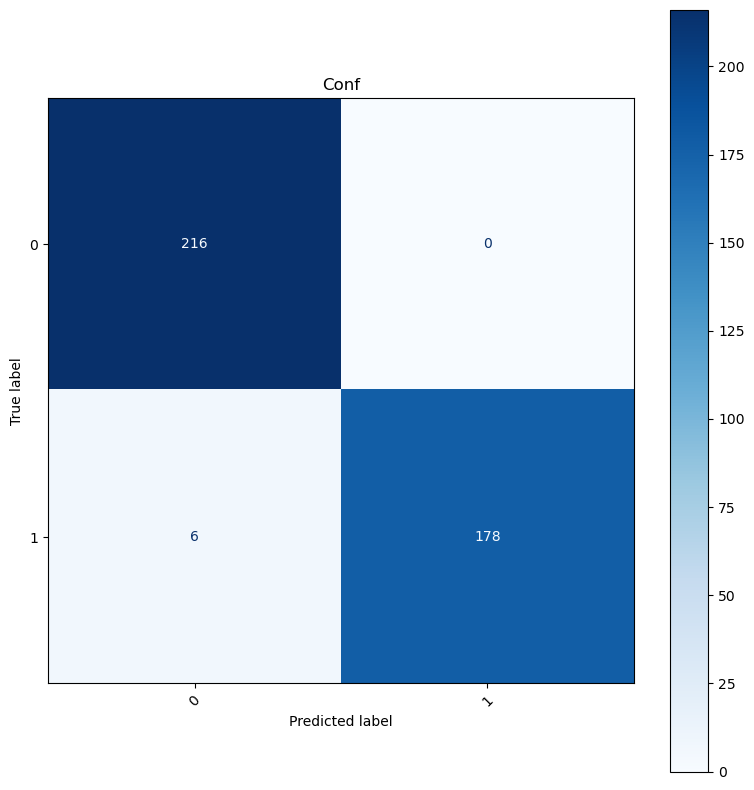

'\n\ndirlist_t = os.listdir(\'media\\clefdata\\lines\\treble\')\ndirlist_b = os.listdir(\'media\\clefdata\\lines\\bass\')\nprint(dirlist_t[0])\n\ncol1_filenum = []\ncol2_category = []\ncol3_clefname = []\n\nfor fileindex in range(len(dirlist_t)):\n    if fileindex >= 2200:\n        break\n    if dirlist_t[fileindex].endswith(\'.png\'):\n        col1_filenum.append(dirlist_t[fileindex][:-4]) # removes the .png part of the filename, leaving just the number.\n        col2_category.append(0)\n        col3_clefname.append(\'treble\')\nfor fileindex in range(len(dirlist_b)):\n    if fileindex >= 1800:\n        break\n    if dirlist_b[fileindex].endswith(\'.png\'):\n        col1_filenum.append(dirlist_b[fileindex][:-4]) # removes the .png part of the filename, leaving just the number.\n        col2_category.append(1)\n        col3_clefname.append(\'bass\')\n\nd = {"filenum": col1_filenum\n     , "category": col2_category\n     , "clefname": col3_clefname}\n\ndf = pd.DataFrame(d)\nprint(df.hea

In [5]:
print("mean squared error:")
print(y_true[0])
print(predictions[0])
print(mean_squared_error(y_true, predictions))

cm = confusion_matrix(y_true,predictions)
print(cm.shape)

disp = ConfusionMatrixDisplay(confusion_matrix = cm
                              , display_labels=[0,1])

import matplotlib.pyplot as plt

flg, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Conf")
plt.tight_layout()
plt.savefig("models/mininet-conf.png")
plt.show()


"""

dirlist_t = os.listdir('media\\clefdata\\lines\\treble')
dirlist_b = os.listdir('media\\clefdata\\lines\\bass')
print(dirlist_t[0])

col1_filenum = []
col2_category = []
col3_clefname = []

for fileindex in range(len(dirlist_t)):
    if fileindex >= 2200:
        break
    if dirlist_t[fileindex].endswith('.png'):
        col1_filenum.append(dirlist_t[fileindex][:-4]) # removes the .png part of the filename, leaving just the number.
        col2_category.append(0)
        col3_clefname.append('treble')
for fileindex in range(len(dirlist_b)):
    if fileindex >= 1800:
        break
    if dirlist_b[fileindex].endswith('.png'):
        col1_filenum.append(dirlist_b[fileindex][:-4]) # removes the .png part of the filename, leaving just the number.
        col2_category.append(1)
        col3_clefname.append('bass')

d = {"filenum": col1_filenum
     , "category": col2_category
     , "clefname": col3_clefname}

df = pd.DataFrame(d)
print(df.head())
print(df.tail())
df.to_csv('media\\clefdata\\lines\\cleflabels.csv', index=False)


img = cv.imread(f'media\\clefdata\\lines\\treble\\{dirlist[0]}'
                , cv.IMREAD_GRAYSCALE)

imgheight, imgwidth = img.shape

cropimg = img[:imgheight, :imgheight]

resizeimg = cv.resize(cropimg, (50,50), interpolation=cv.INTER_NEAREST)

cv.imshow("Displayed Image", resizeimg)
cv.waitKey(0)
cv.destroyAllWindows()
"""

In [12]:
torch.save(model.state_dict(), 'mininet.pth')

In [11]:
with torch.no_grad():
    model.eval()
    """
    num = 0
    print(images[num].shape)
    print(images[num][0].shape)
    img = torch.tensor(np.expand_dims(images[num], axis=0))
    res = model(img)
    img = np.array(img)
    print(img.shape)
    """

    for entry in images:
        img = torch.tensor(np.expand_dims(entry, axis=0))
        res = model(img)
        arr = np.array(img)
        print(arr.shape)
        cv.imshow(str(np.argmax(res))
          ,cv.resize(arr[0][0],(500,500)))
        cv.waitKey(0)
        cv.destroyAllWindows()

"""
cv.imshow(str(np.argmax(res))
          ,cv.resize(img[0][0],(500,500)))
cv.waitKey(0)
cv.destroyAllWindows()
"""

(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)
(1, 1, 50, 50)


'\ncv.imshow(str(np.argmax(res))\n          ,cv.resize(img[0][0],(500,500)))\ncv.waitKey(0)\ncv.destroyAllWindows()\n'